In [2]:
import pandas as pd

df_entero = pd.read_csv('clean.csv', sep=';')

columnas_criticas = df_entero.columns[:-1]

df = df_entero.dropna(subset=columnas_criticas)

print(f"Filas originales: {len(df_entero)}")
print(f"Filas tras limpieza: {len(df)}")

Filas originales: 696
Filas tras limpieza: 229


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt
import numpy as np

In [4]:
seed = 1

X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns = ["mat1BAC", "mat2BAC"]),
                                        df['mat1BAC'],
                                        random_state = seed
                                    )

Text(0.5, 1.0, 'R2 de validación cruzada vs hiperparámetro ccp_alpha en regresion')

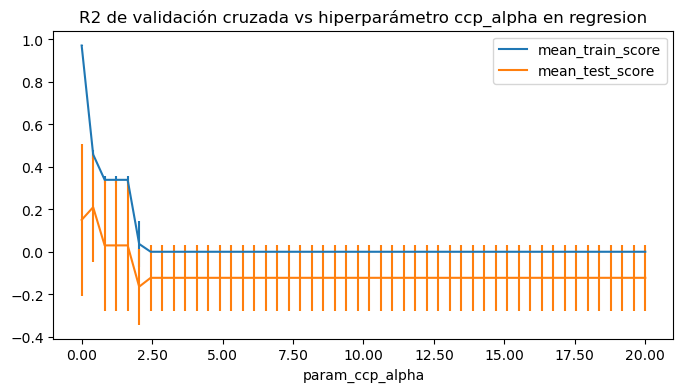

In [5]:
from matplotlib.ticker import FormatStrFormatter
param_grid = {'ccp_alpha':np.linspace(0, 20)}


grid = GridSearchCV(
        estimator = DecisionTreeRegressor(
                            max_depth         = None,
                            min_samples_split = 2,
                            min_samples_leaf  = 1,
                            random_state      = seed
                       ),
        param_grid = param_grid,
        cv         = 10,
        refit      = True,
        return_train_score = True
      )

grid.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(8, 4))
scores = pd.DataFrame(grid.cv_results_)
scores.plot(x='param_ccp_alpha', y='mean_train_score', yerr='std_train_score', ax=ax)
scores.plot(x='param_ccp_alpha', y='mean_test_score', yerr='std_test_score', ax=ax)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_title("R2 de validación cruzada vs hiperparámetro ccp_alpha en regresion")

Profundidad del árbol: 2
Número de nodos terminales: 3


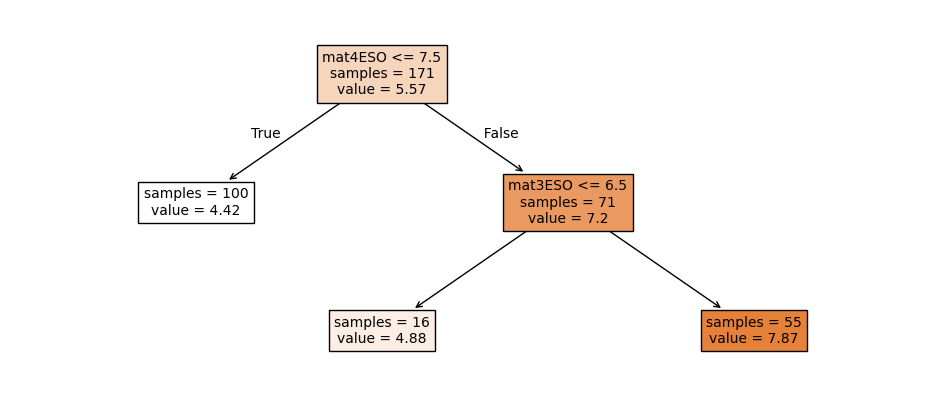

In [6]:
modelo = grid.best_estimator_

fig, ax = plt.subplots(figsize=(12, 5))

print(f"Profundidad del árbol: {modelo.get_depth()}")
print(f"Número de nodos terminales: {modelo.get_n_leaves()}")

plot = plot_tree(
            decision_tree = modelo,
            feature_names = df.drop(columns = 'mat1BAC').columns,
            class_names   = None,
            filled        = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

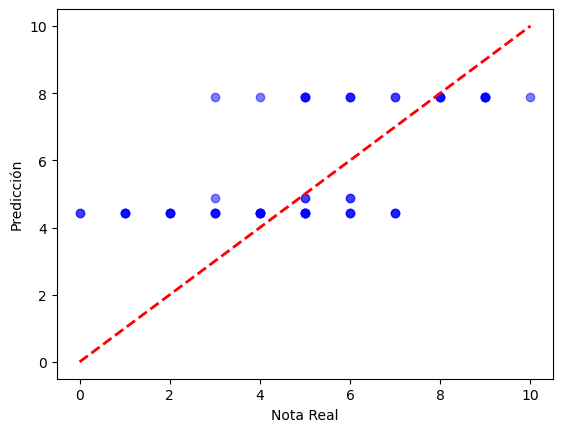

In [7]:
import matplotlib.pyplot as plt

y_pred = modelo.predict(X_test)

plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nota Real')
plt.ylabel('Predicción')
plt.show()

In [8]:
predicciones = modelo.predict(X = X_test)

mae_dt = mean_absolute_error(
        y_true  = y_test,
        y_pred  = predicciones
       )
print(f"El error (mae) de test es: {mae_dt:.2f}")

El error (mae) de test es: 1.67
